# qc figs

**Pinned Environment:** [`envs/sc-spatial.yaml`](../.../envs/sc-spatial.yaml)  

In [31]:
import os
from pathlib import Path
import scanpy as sc
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import anndata as ad
import session_info

In [32]:
plt.rcParams['figure.dpi'] = 200

In [33]:
base_dir = Path('/home/workspace/projects/drg')
input_dir = os.path.join(base_dir, 'data/h5ad/export_01/01b_filter/')
fig_dir = os.path.join(base_dir, 'figures/qc/') # where to save qc viz

In [34]:
file_name = os.path.join(input_dir, 'adata-475.h5ad')
adata = sc.read_h5ad(file_name)

## Visualize qc metrics

TMA00304


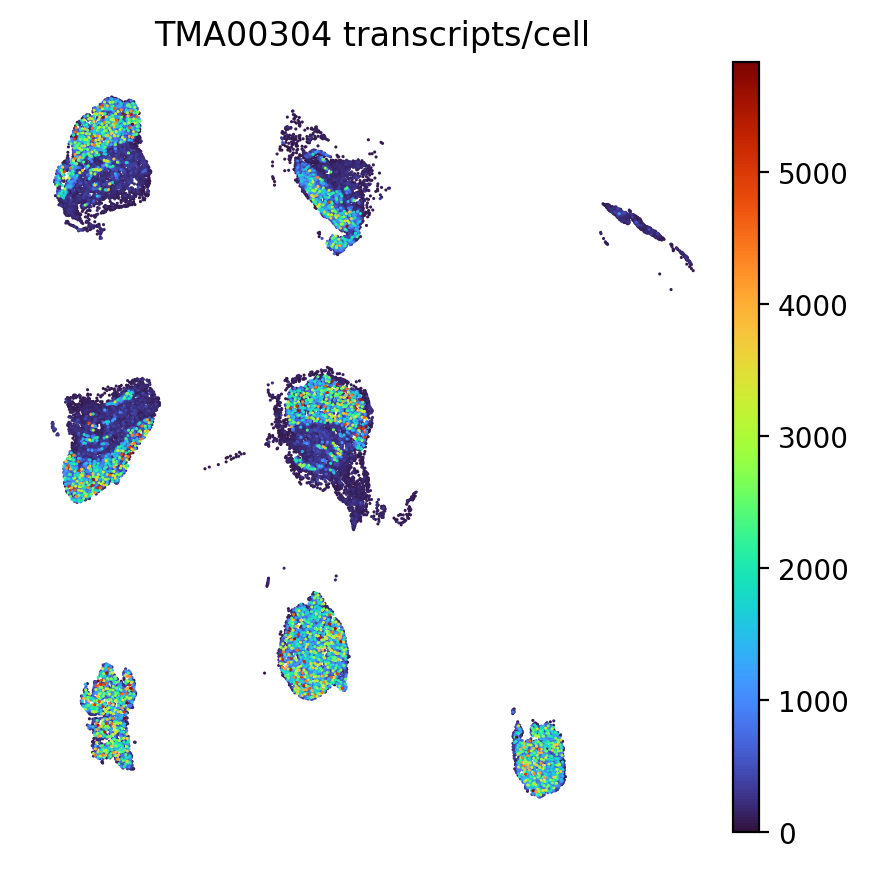

TMA00306


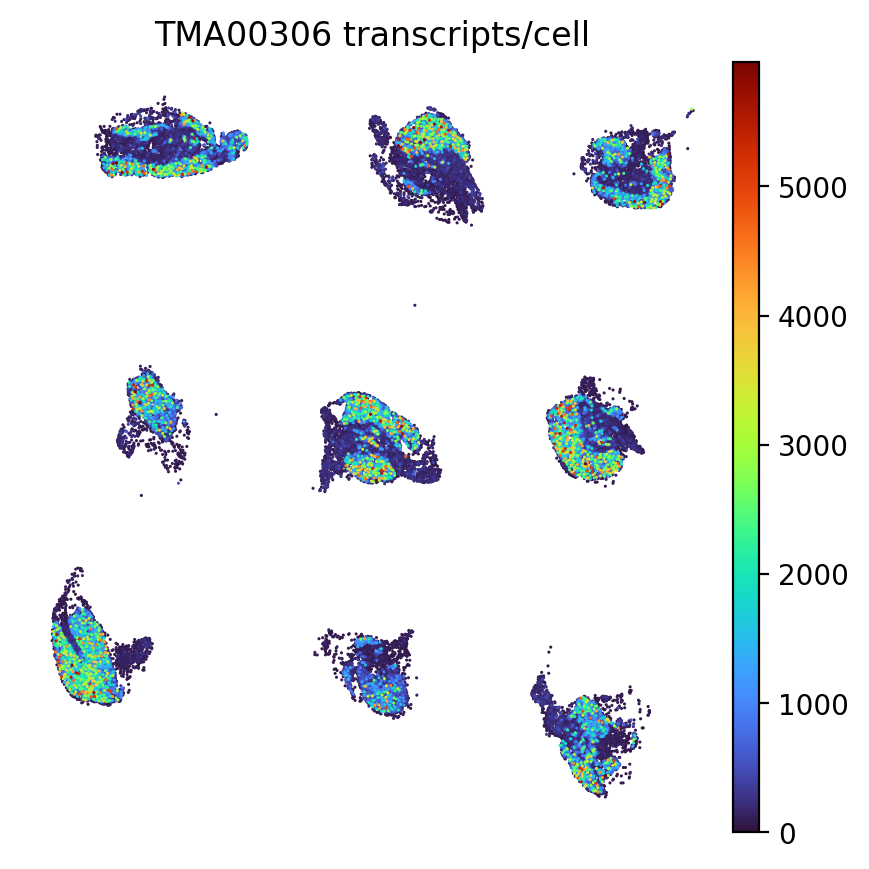

TMA00313


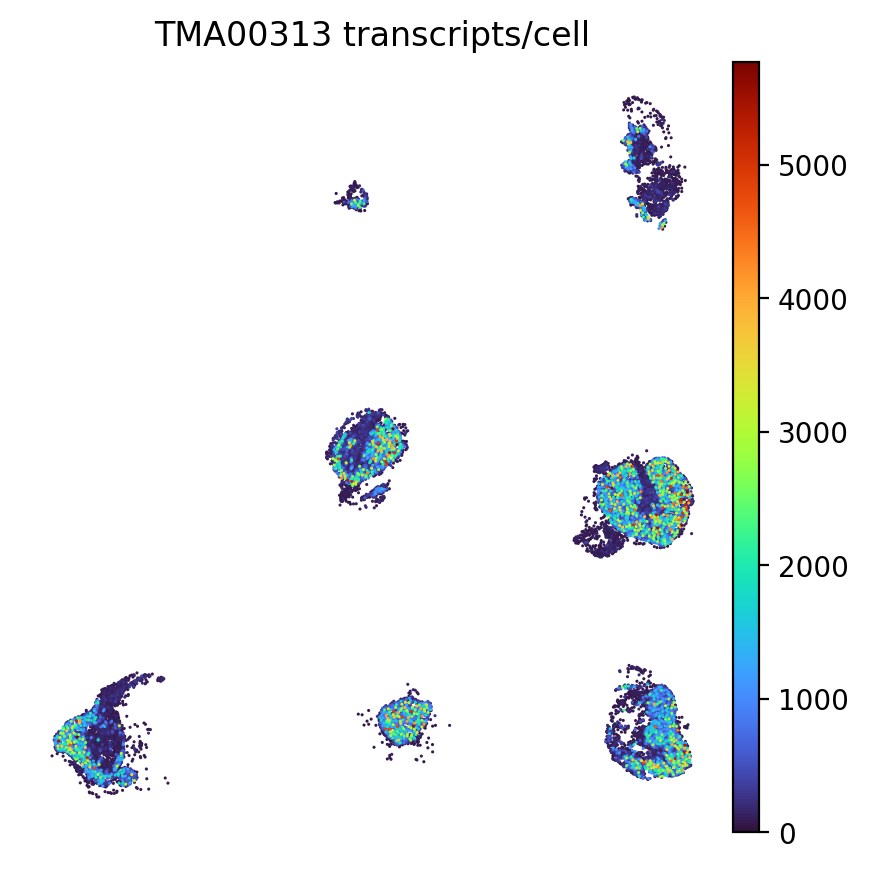

TMA00311


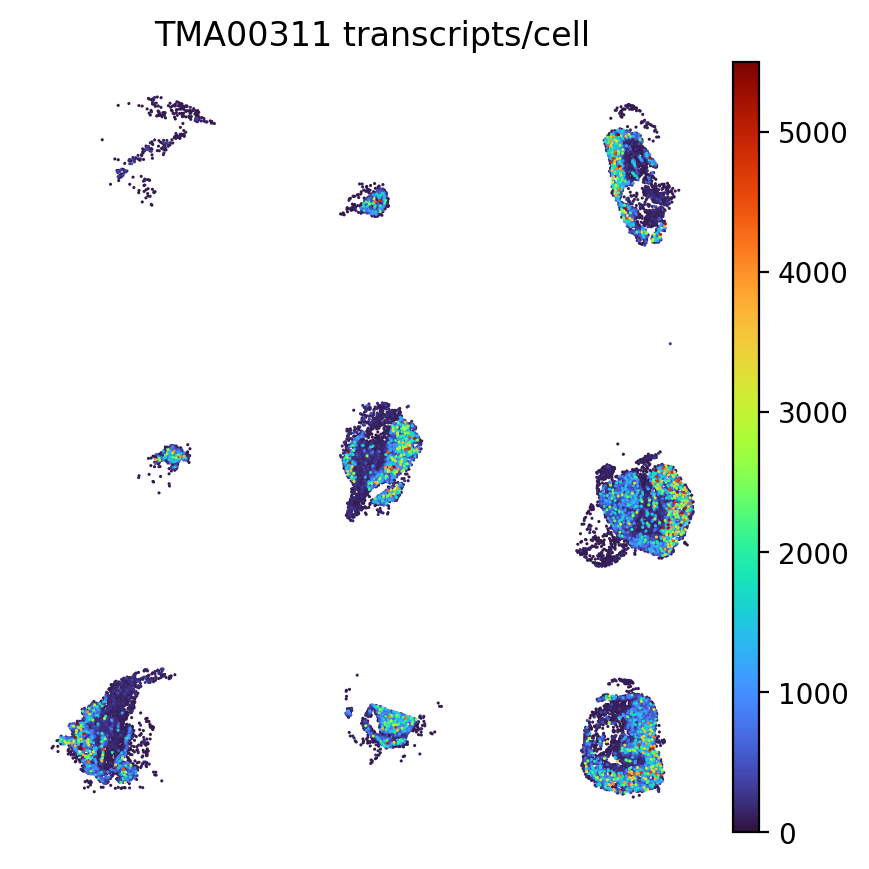

TMA00308


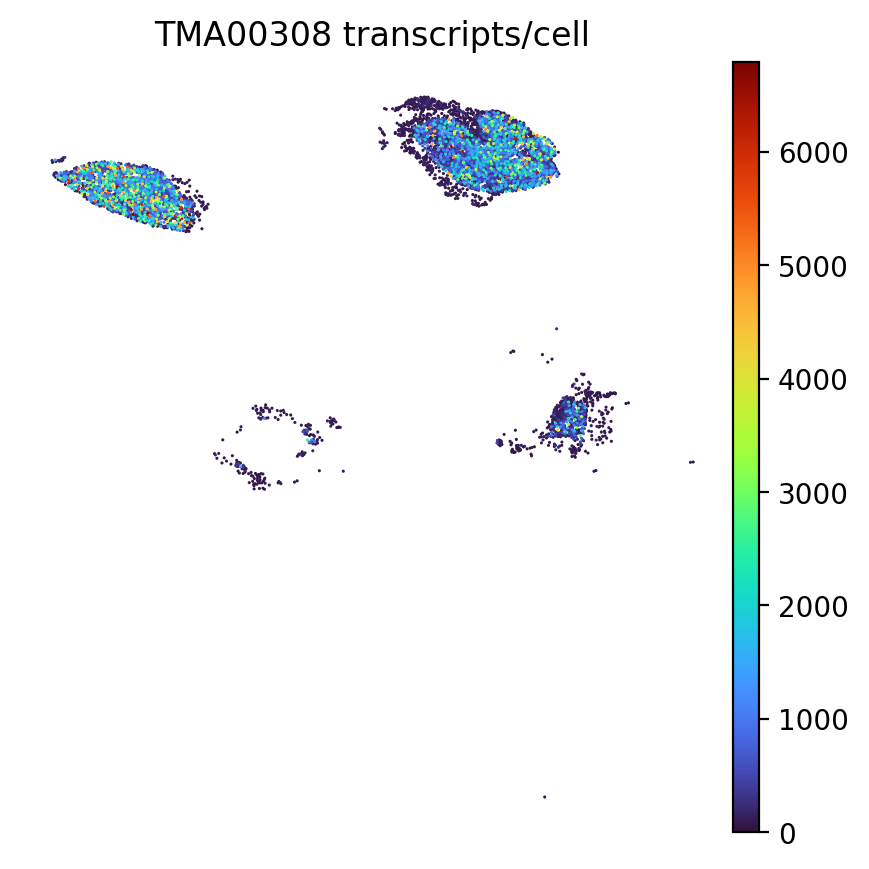

TMA00303


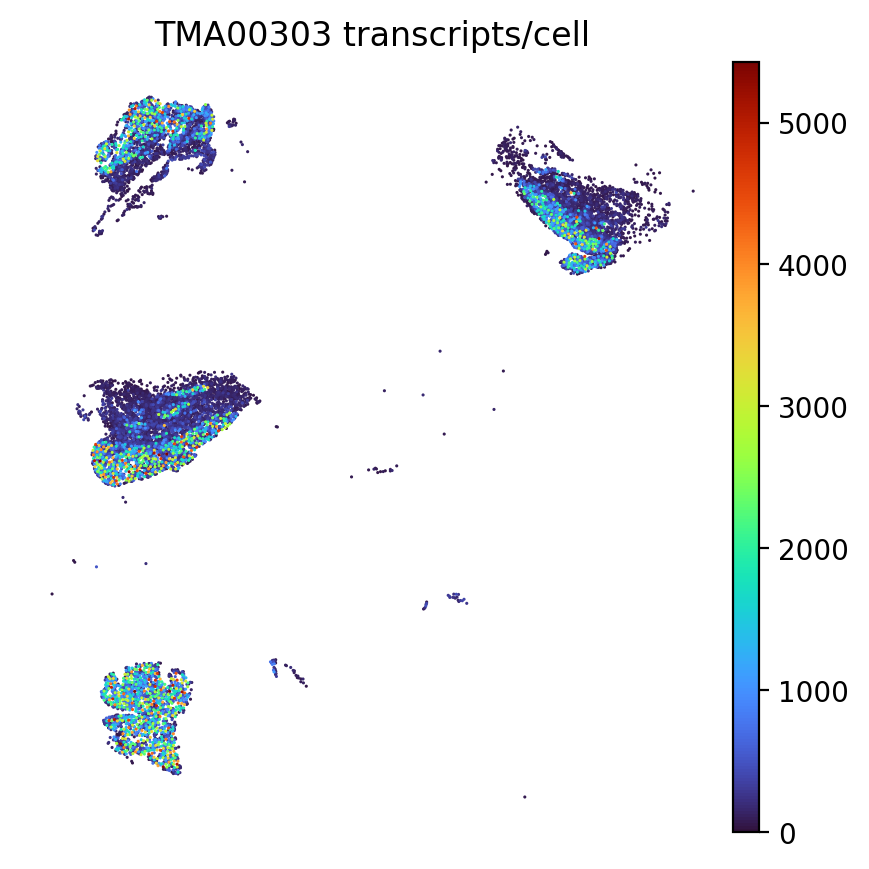

TMA00310


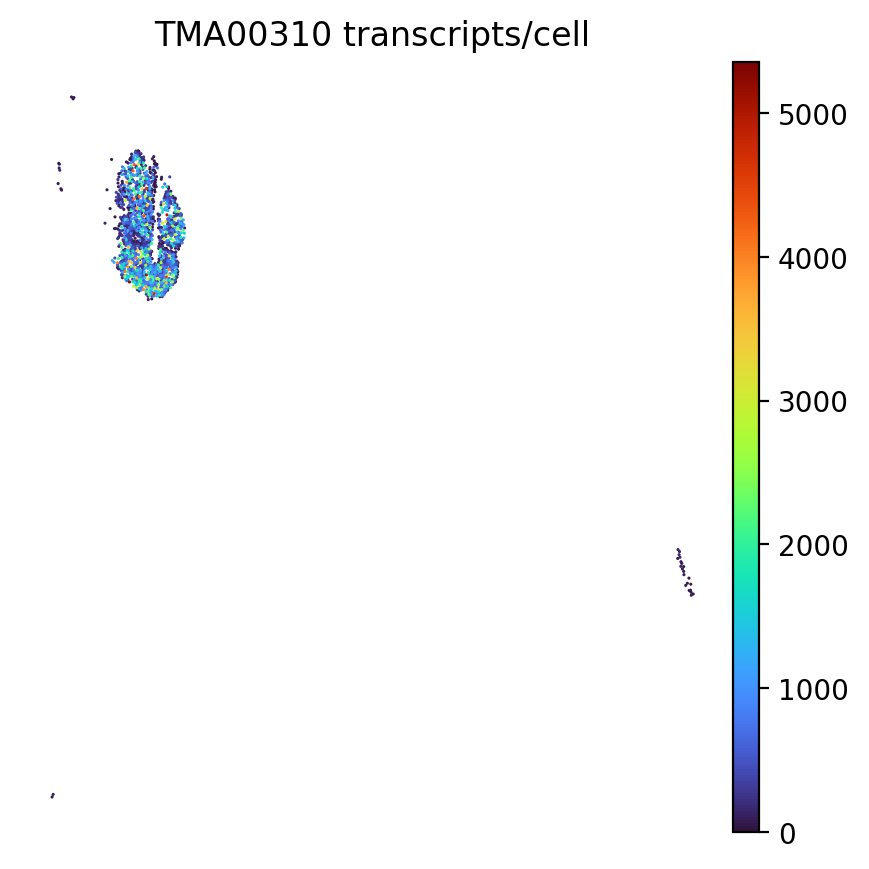

TMA00305


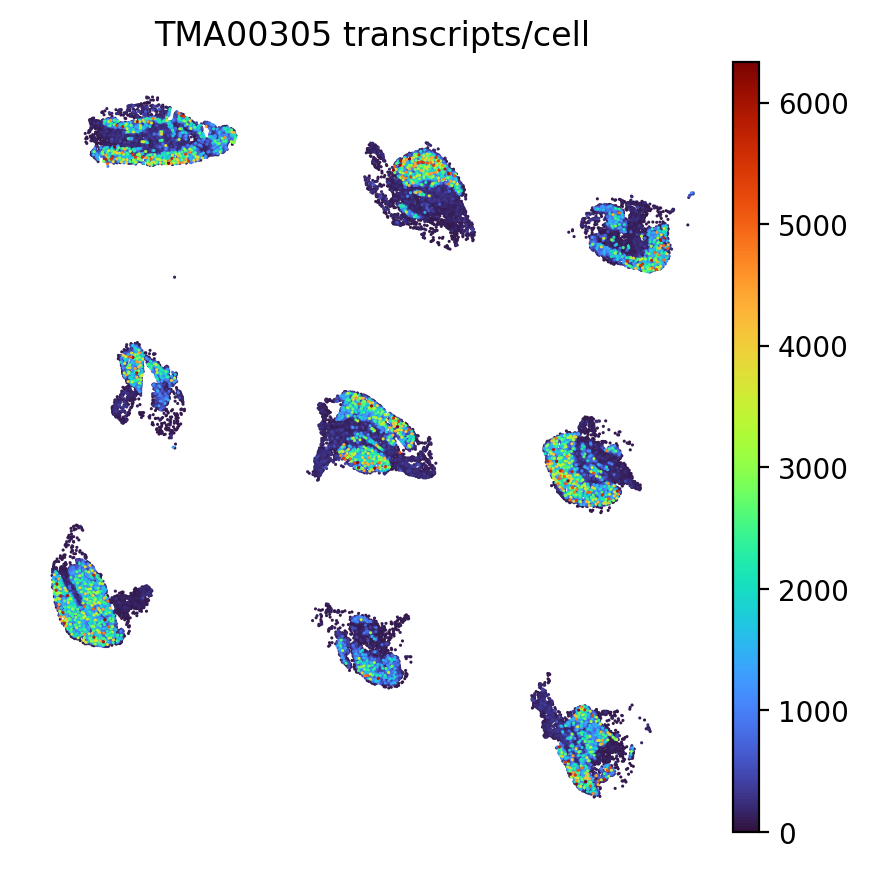

TMA00309


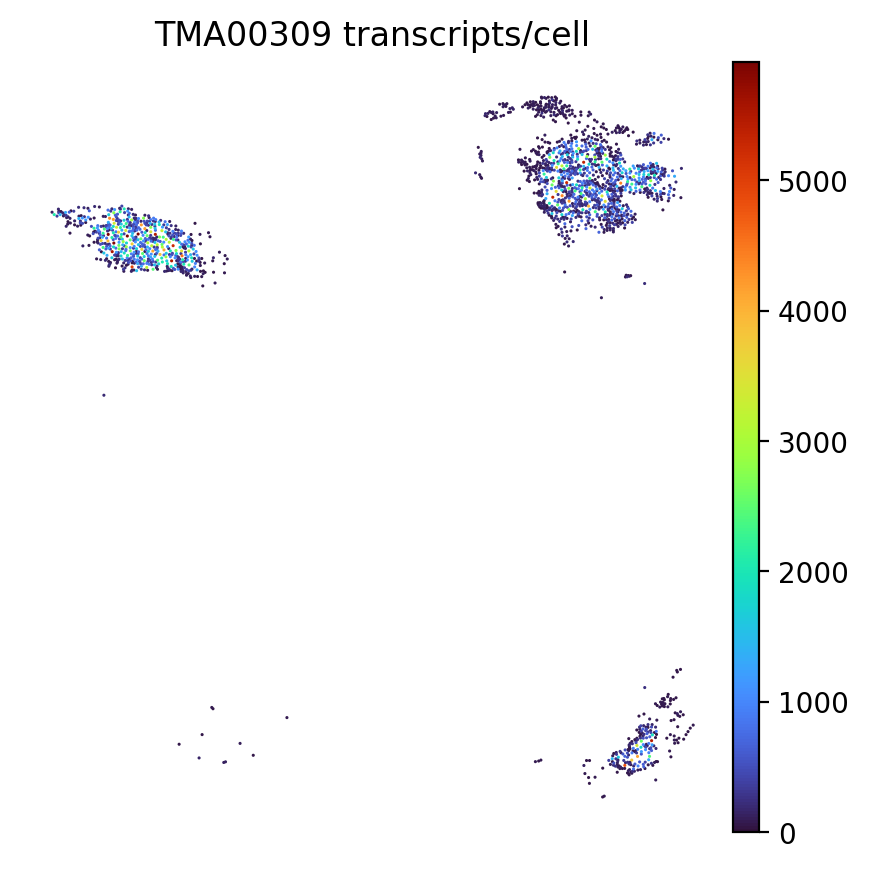

TMA00307


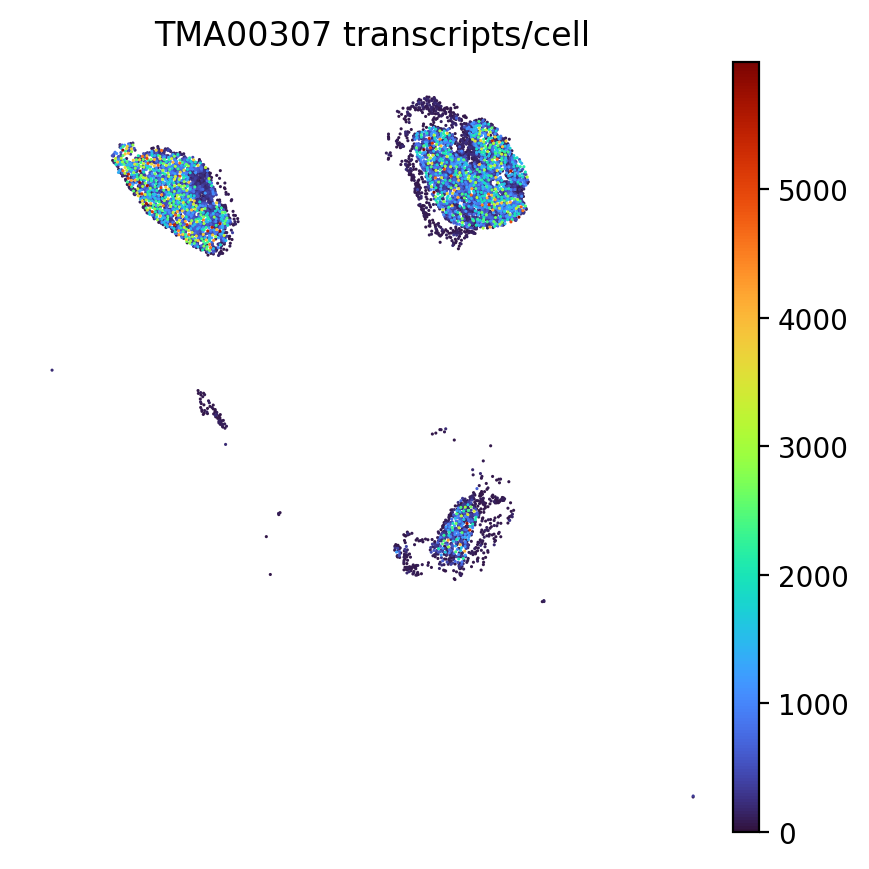

TMA00312


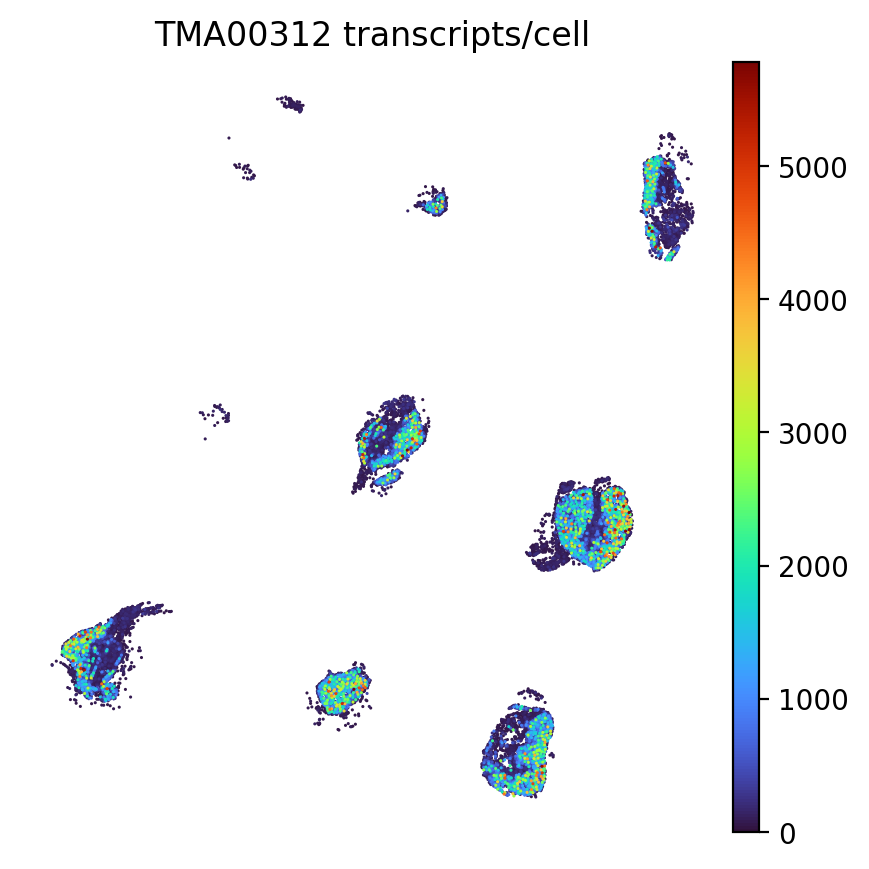

TMA00314


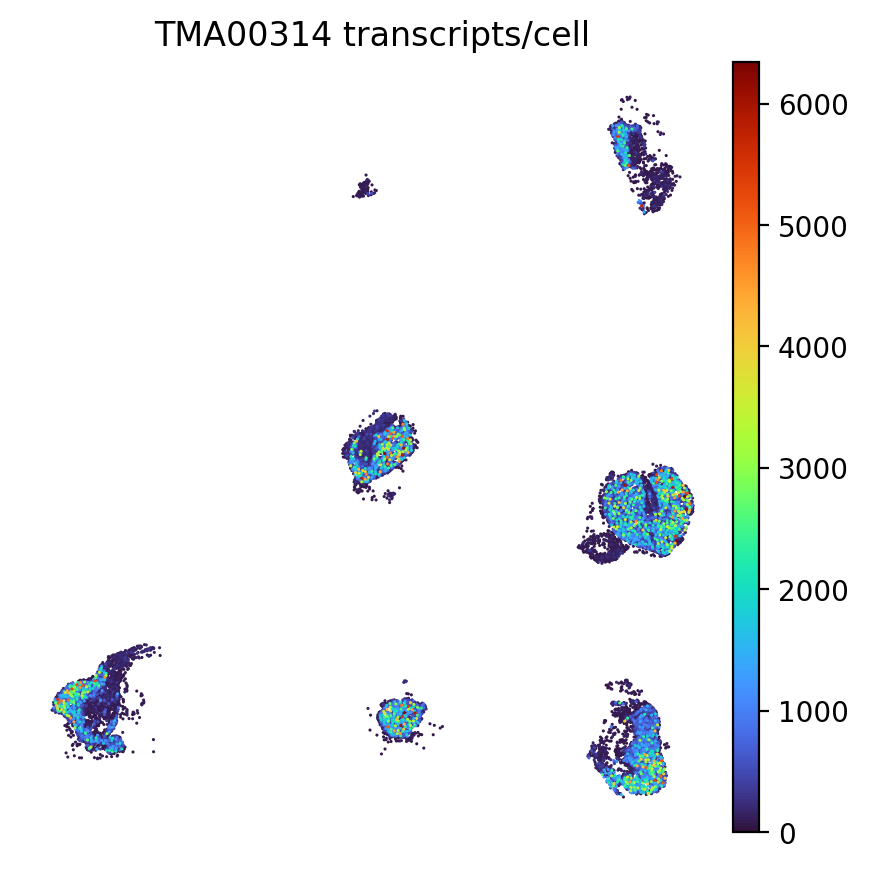

In [36]:
for sample_id in adata.obs['sample_id'].unique():
    print(sample_id)

    # Subset to the current sample
    adata_sub = adata[adata.obs['sample_id'] == sample_id, :]

    # Plot and save
    fig, ax = plt.subplots(figsize=(5, 5))
    sc.pl.embedding(
        adata_sub,
        basis='spatial',
        color='total_counts',
        title=f'{sample_id} transcripts/cell',
        vmin=0,
        #vmax=5000,
        size=5,
        ax=ax,
        frameon=False,
        cmap = 'turbo'
    )
    #fig.savefig(os.path.join(fig_dir, f'{sample_id}_spatial_QC.png'))
    plt.close(fig)

In [ ]:
adata.obs.columns

TMA00304


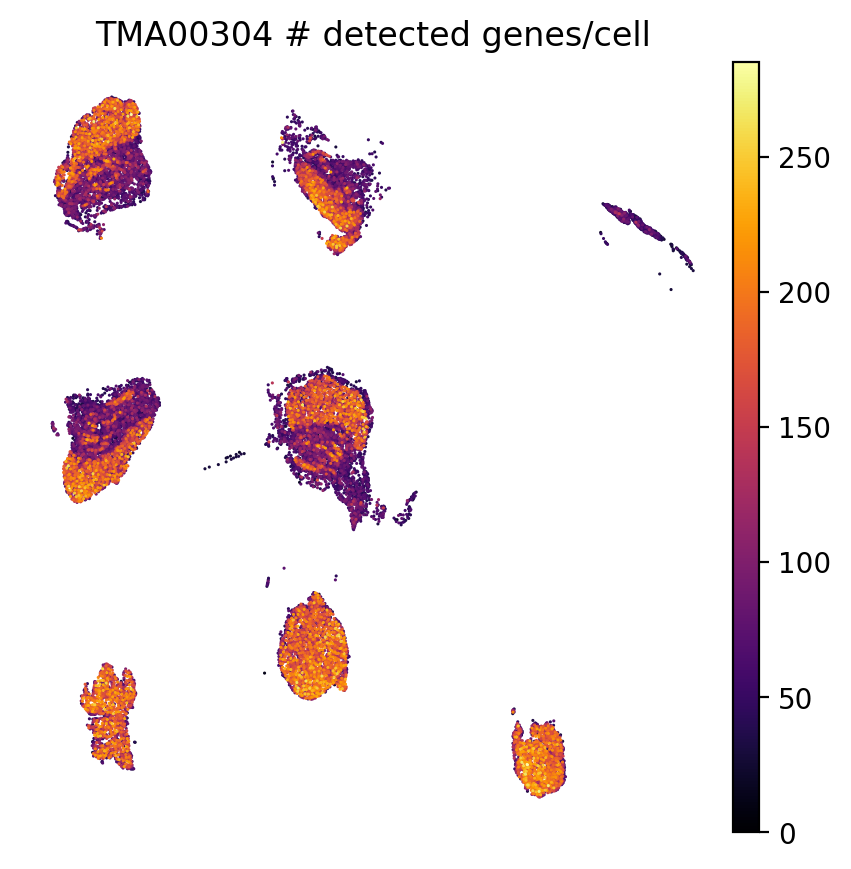

TMA00306


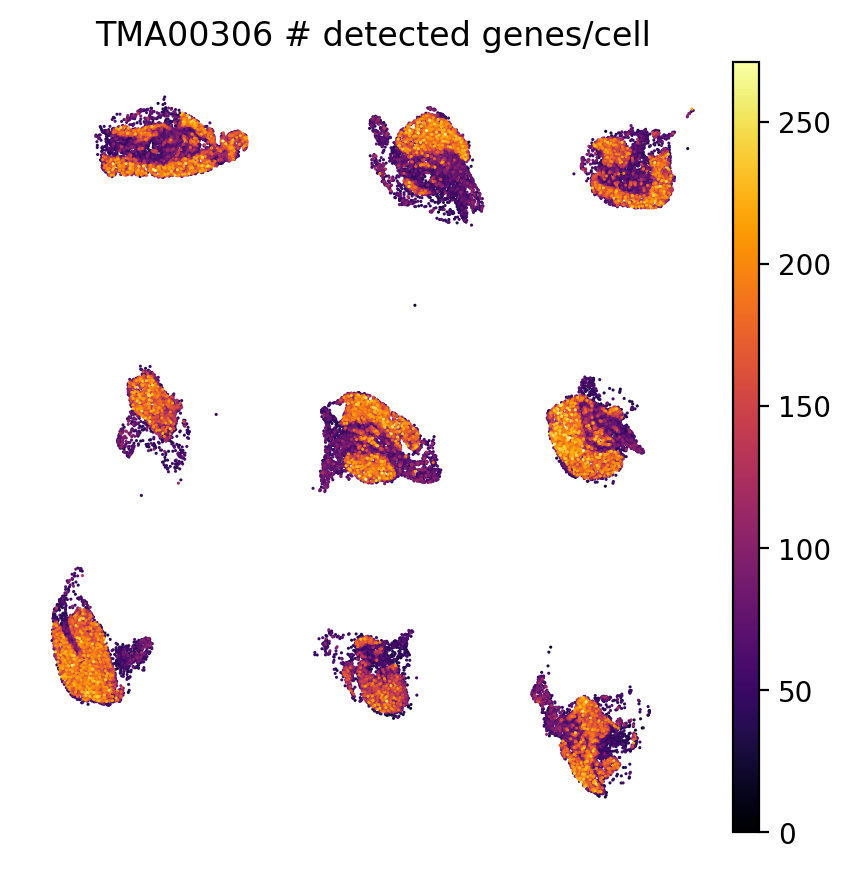

TMA00313


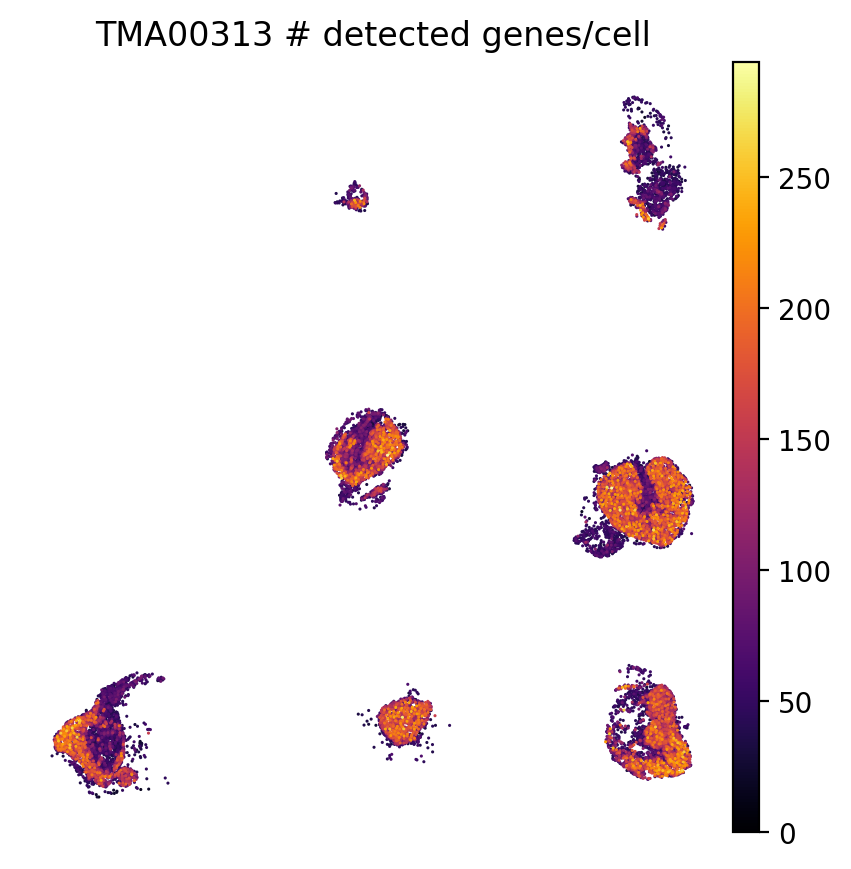

TMA00311


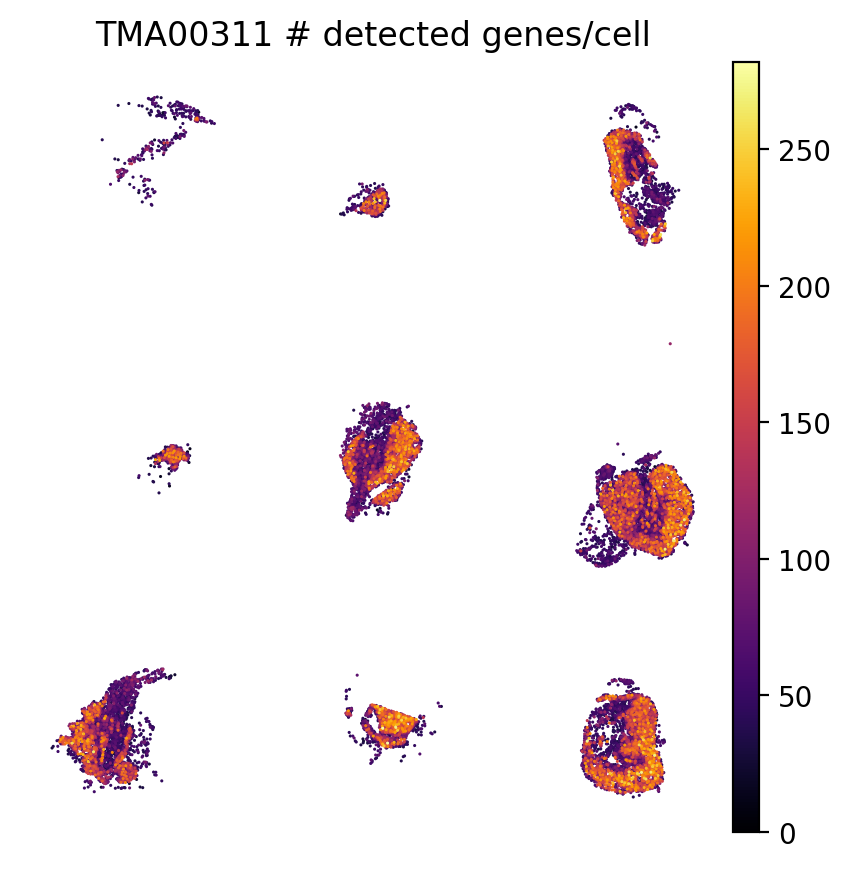

TMA00308


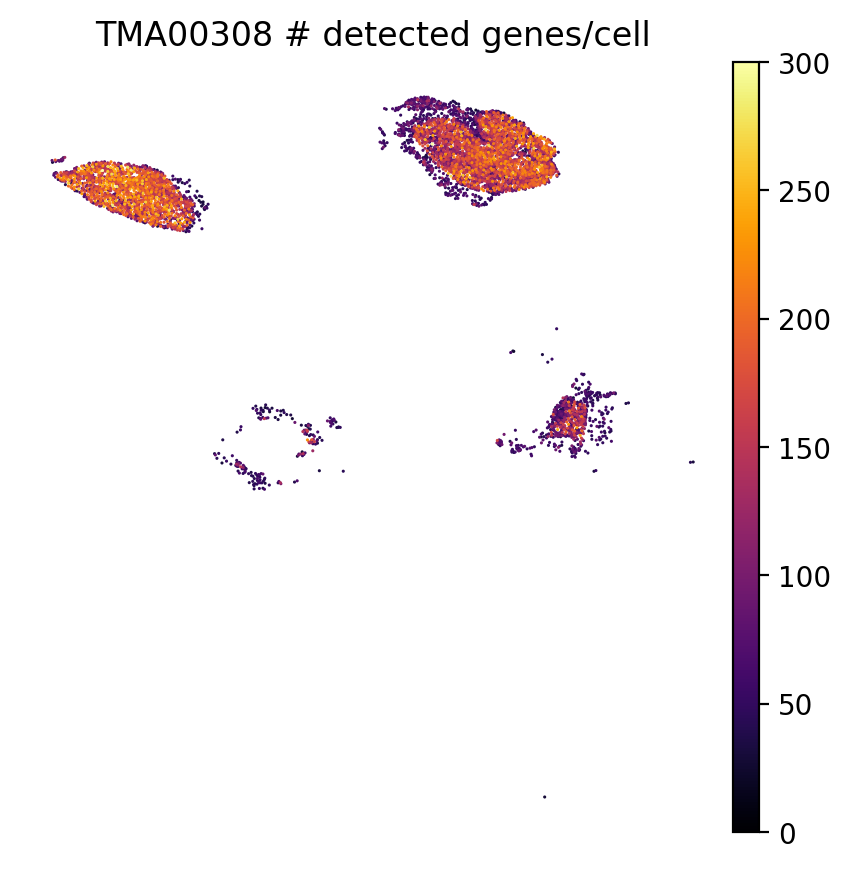

TMA00303


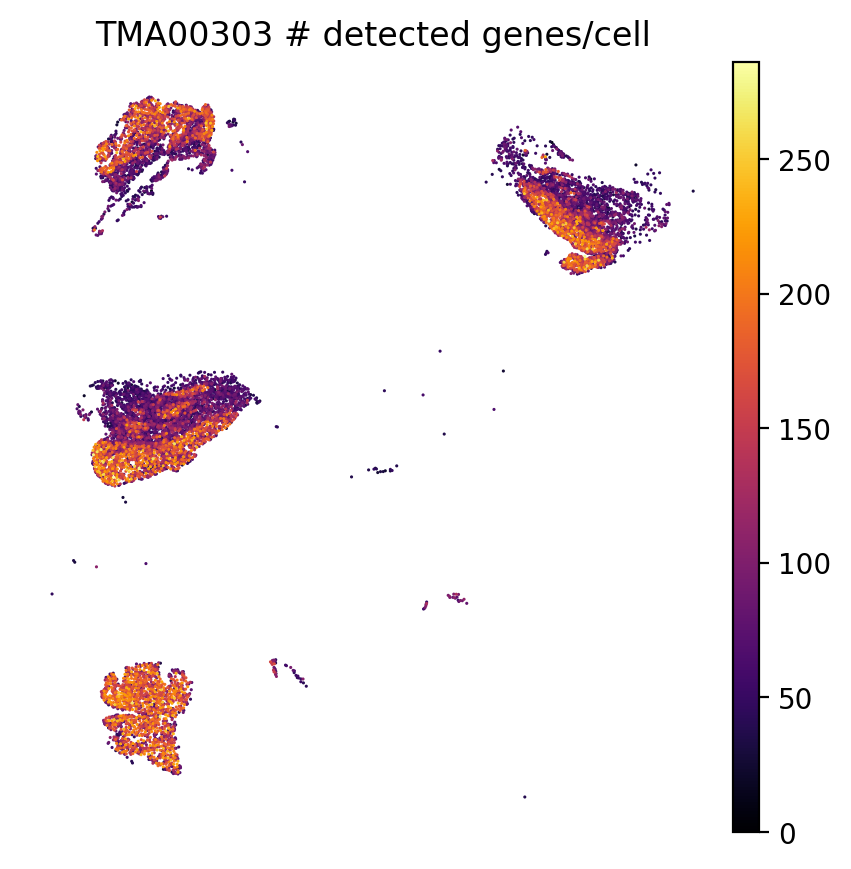

TMA00310


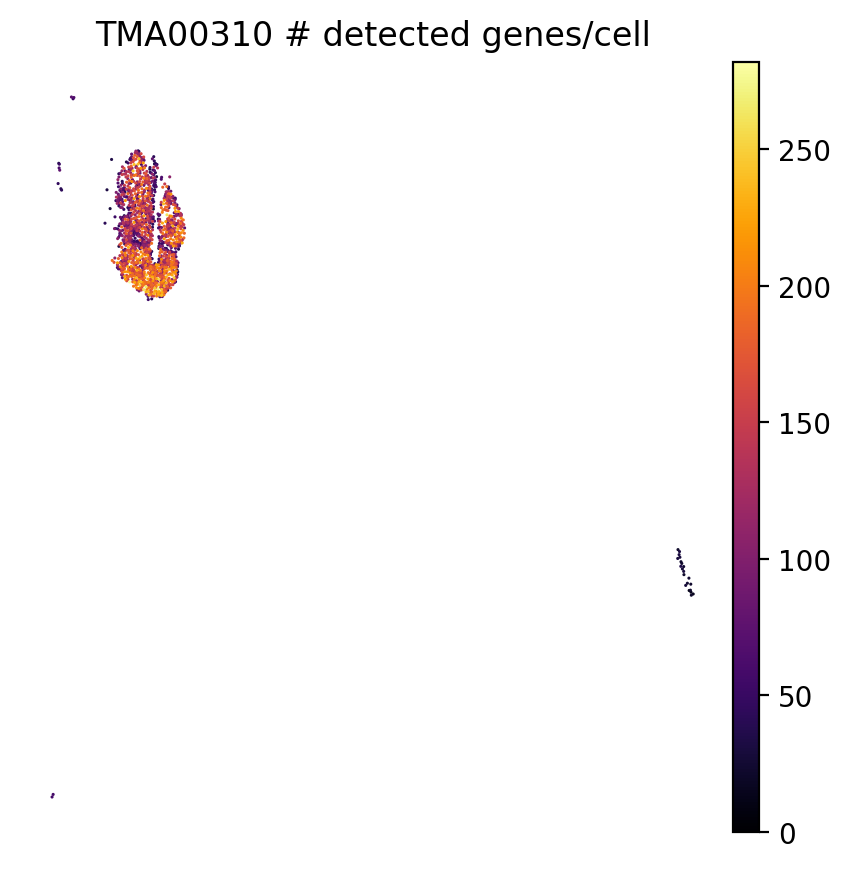

TMA00305


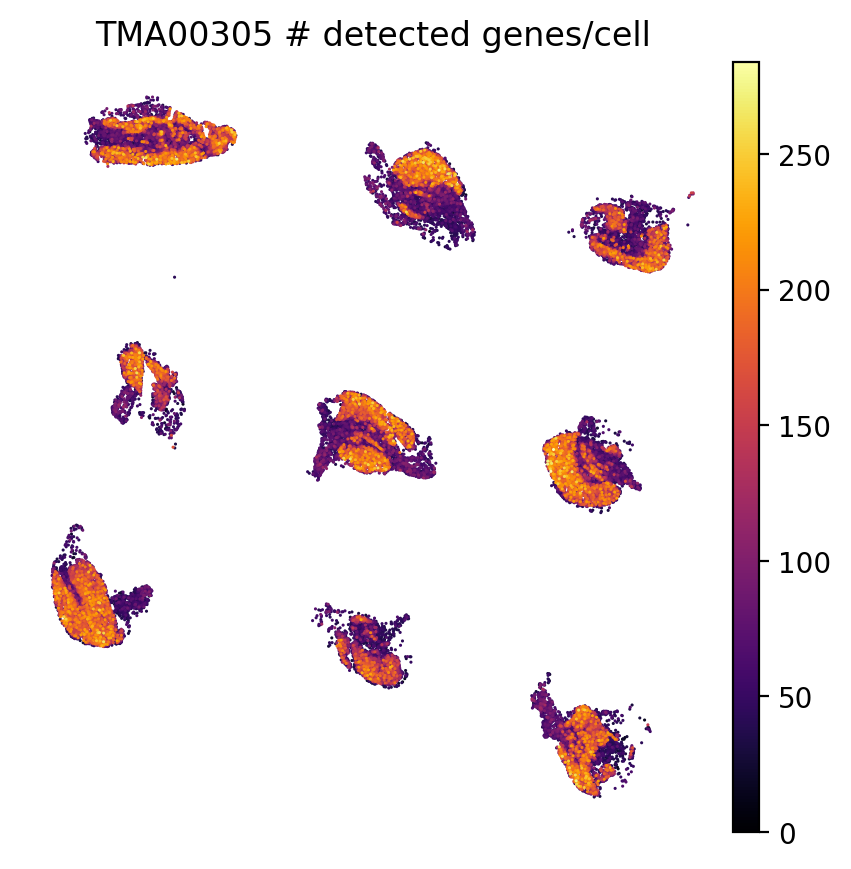

TMA00309


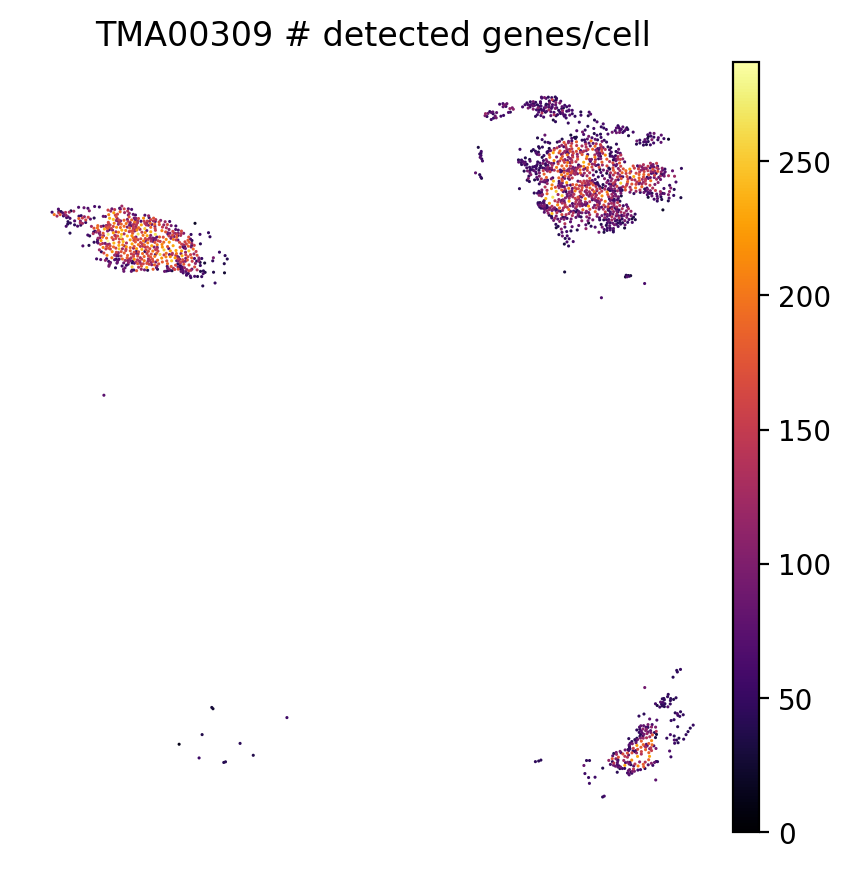

TMA00307


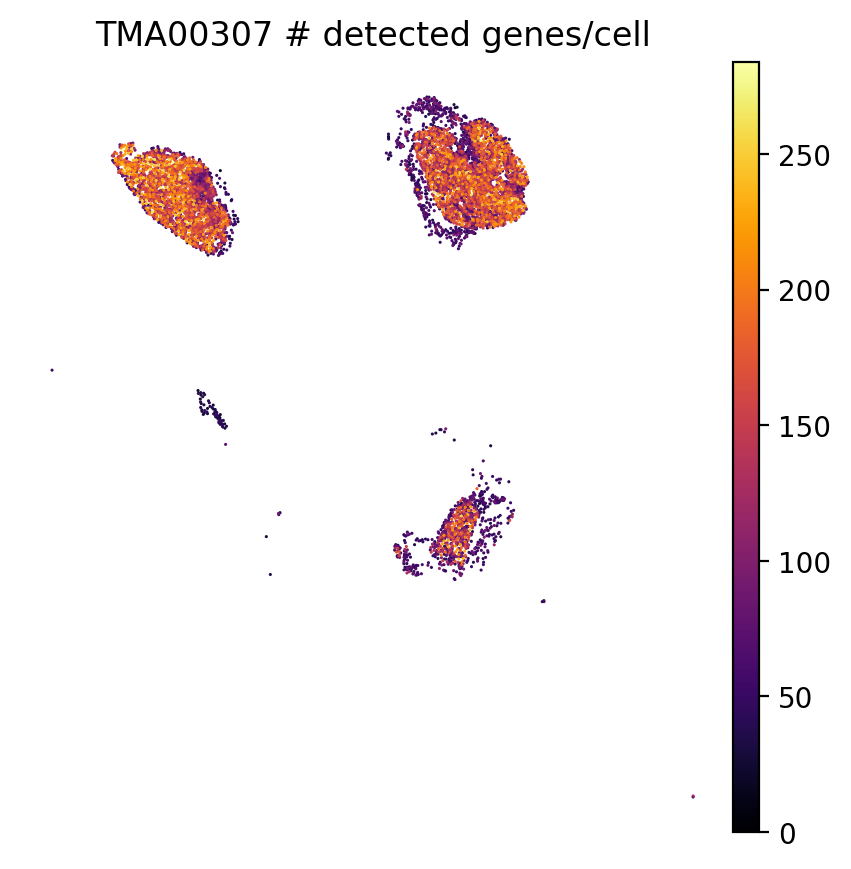

TMA00312


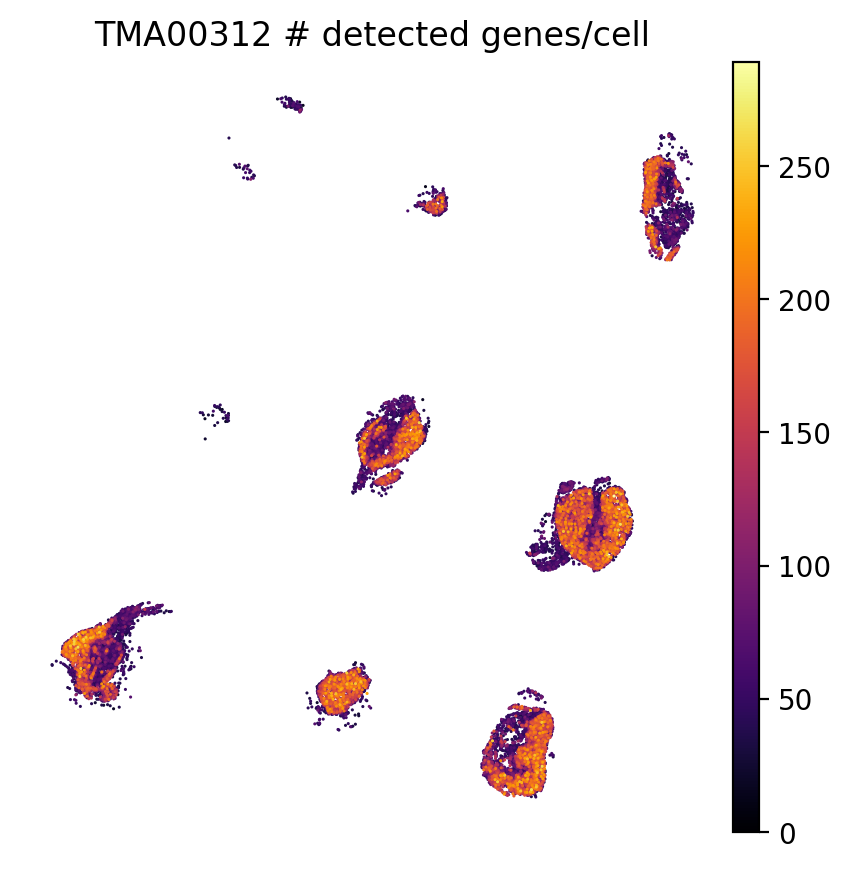

TMA00314


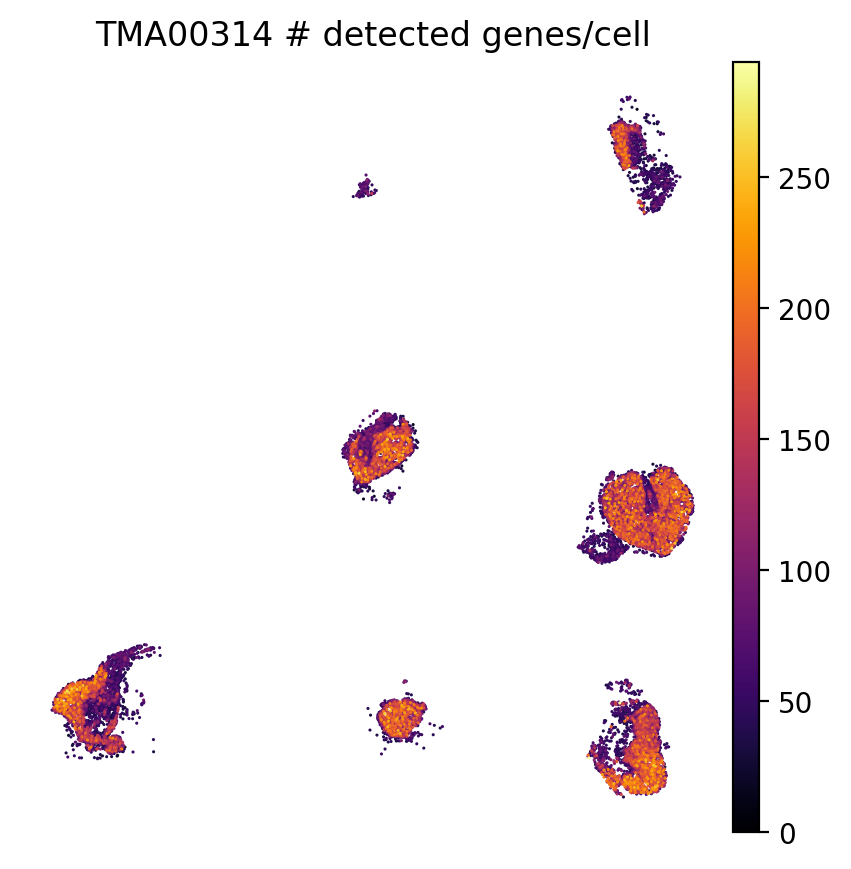

In [35]:
for sample_id in adata.obs['sample_id'].unique():
    print(sample_id)

    # Subset to the current sample
    adata_sub = adata[adata.obs['sample_id'] == sample_id, :]

    # Plot and save
    fig, ax = plt.subplots(figsize=(5, 5))
    sc.pl.embedding(
        adata_sub,
        basis='spatial',
        color='n_genes_by_counts',
        title=f'{sample_id} # detected genes/cell',
        vmin=0,
        #vmax=100,
        size=5,
        ax=ax,
        frameon=False,
        cmap = 'inferno'
    )
    #fig.savefig(os.path.join(fig_dir, f'{sample_id}_spatial_QC.png'))
    plt.close(fig)

In [ ]:
for sample_id in adata.obs['sample_id'].unique():
    print(sample_id)

    # Subset to the current sample
    adata_sub = adata[adata.obs['sample_id'] == sample_id, :]

    # Plot and save
    fig, ax = plt.subplots(figsize=(5, 5))
    sc.pl.embedding(
        adata_sub,
        basis='spatial',
        color='segmentation_method',
        palette = 'Paired',
        title=f'{sample_id} segmentation',
        #vmin=0,
        #vmax=100,
        size=10,
        ax=ax,
        frameon=False
    )
    fig.savefig(os.path.join(fig_dir, f'{sample_id}_segmentation_spatial_QC.png'))
    plt.close(fig)

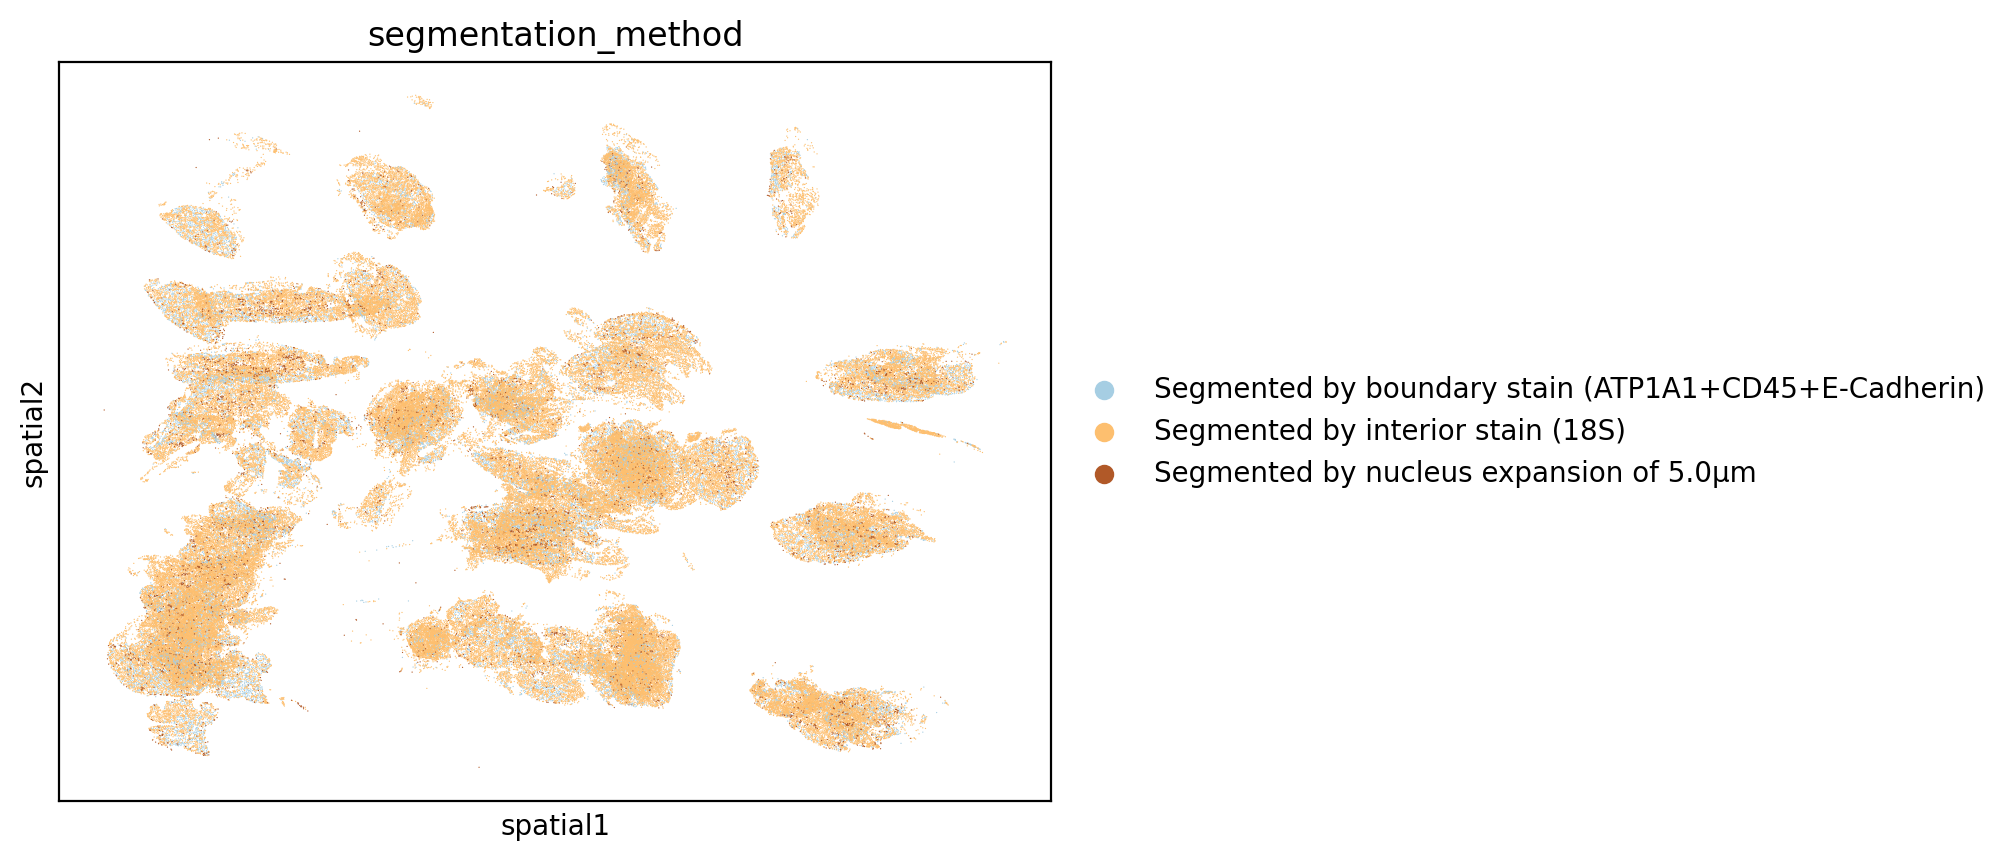

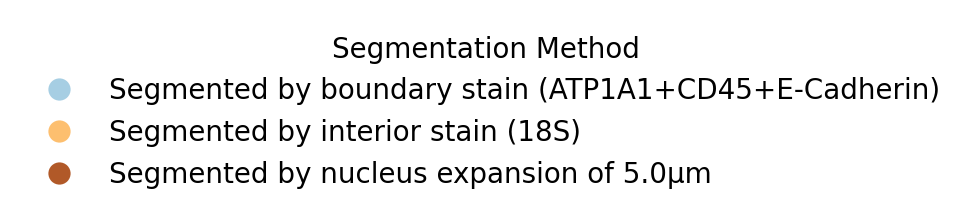

In [7]:
# 1) Make sure segmentation_method is categorical
adata.obs['segmentation_method'] = adata.obs['segmentation_method'].astype('category')

# 2) Ensure Scanpy has assigned colors using the Paired palette (run once)
if 'segmentation_method_colors' not in adata.uns:
    sc.pl.embedding(
        adata,
        basis='spatial',
        color='segmentation_method',
        palette='Paired',
        show=False
    )

# 3) Build legend from the stored colors (this WILL match your spatial plots)
methods = adata.obs['segmentation_method'].cat.categories
colors = adata.uns['segmentation_method_colors']

fig, ax = plt.subplots(figsize=(3, len(methods) * 0.4))
ax.axis("off")

handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=colors[i],
        markeredgecolor='none',
        markersize=8,
        label=method
    )
    for i, method in enumerate(methods)
]

ax.legend(
    handles=handles,
    loc='center',
    frameon=False,
    title='Segmentation Method',
    ncol=1
)

plt.show()
# (Optional)
# fig.savefig(os.path.join(fig_dir, "segmentation_method_legend.png"),
#             bbox_inches="tight", dpi=300)

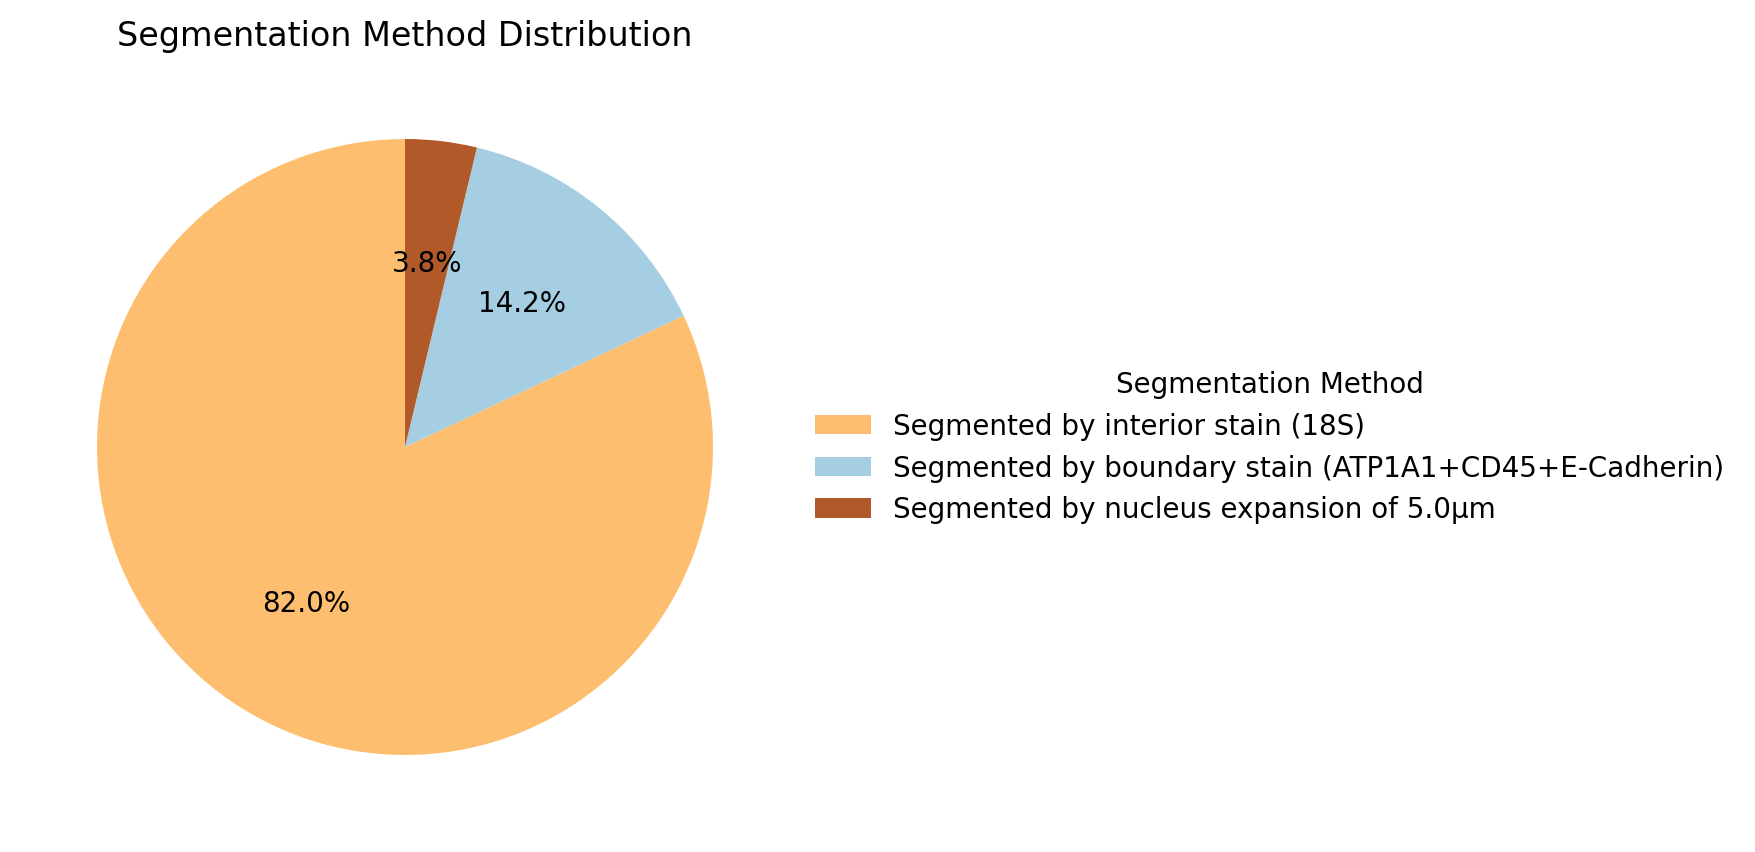

In [8]:
import matplotlib.pyplot as plt

counts = adata.obs['segmentation_method'].value_counts()
labels = counts.index
sizes = counts.values

colors = [
    adata.uns['segmentation_method_colors'][
        list(adata.obs['segmentation_method'].cat.categories).index(l)
    ]
    for l in labels
]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,         
    autopct='%1.1f%%',    
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10},
)

# Add a legend to identify slices
ax.legend(
    wedges,
    labels,
    title="Segmentation Method",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

ax.set_title("Segmentation Method Distribution", fontsize=12)
plt.show()

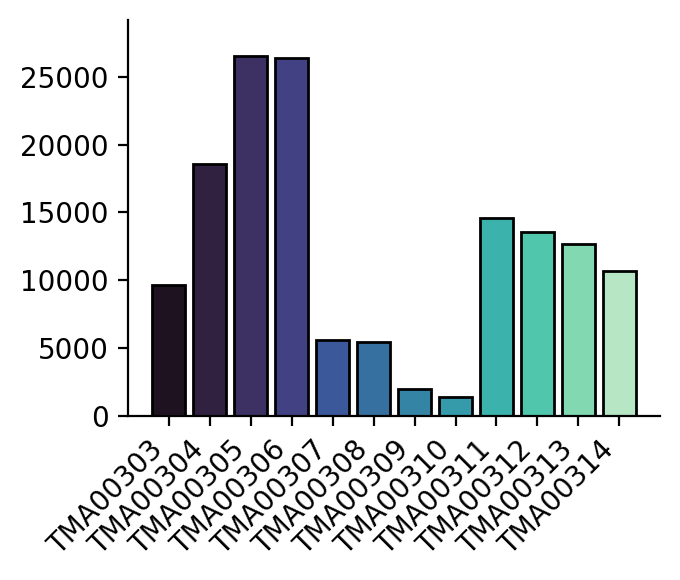

In [9]:
# Count cells per section (sample_id)
cell_counts = adata.obs["sample_id"].value_counts().sort_index()

# Bar labels and counts
panel_names = cell_counts.index.tolist()
counts = cell_counts.values

# Colors
colors = sns.color_palette("mako", len(panel_names))

# Plot
plt.figure(figsize=(3.5, 3))
bars = plt.bar(panel_names, counts, color=colors, edgecolor="black")

# --- Remove annotations (commented out) ---
# for bar in bars:
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width()/2,
#         height + (0.01 * max(counts)),
#         f"{int(height):,}",
#         ha="center",
#         fontsize=10
#     )

# plt.ylabel("# Cells", fontsize=12)
# plt.title("Total Cells per tissue array", fontsize=13)

plt.ylim(0, max(counts) * 1.1)
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

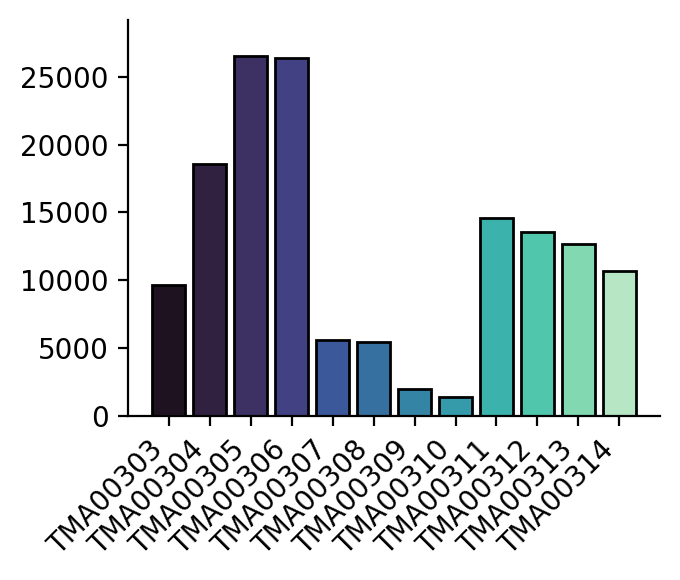

In [21]:
# Count cells per section (sample_id)
cell_counts = adata.obs["sample_id"].value_counts().sort_index()

# Bar labels and counts
panel_names = cell_counts.index.tolist()
counts = cell_counts.values

# Colors
colors = sns.color_palette("mako", len(panel_names))

# Plot
plt.figure(figsize=(3.5, 3))
bars = plt.bar(panel_names, counts, color=colors, edgecolor="black")

# --- Remove annotations (commented out) ---
# for bar in bars:
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width()/2,
#         height + (0.01 * max(counts)),
#         f"{int(height):,}",
#         ha="center",
#         fontsize=10
#     )

# plt.ylabel("# Cells", fontsize=12)
# plt.title("Total Cells per tissue array", fontsize=13)

plt.ylim(0, max(counts) * 1.1)
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

In [10]:
adata.obs.slide_id.value_counts()

slide_id
0052334    44925
0052281    36218
0052046    20177
0052399    18966
0051689    14644
0051805    12106
Name: count, dtype: int64

/tmp/ipykernel_14359/1093384669.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["sample_id", "slide_id"])


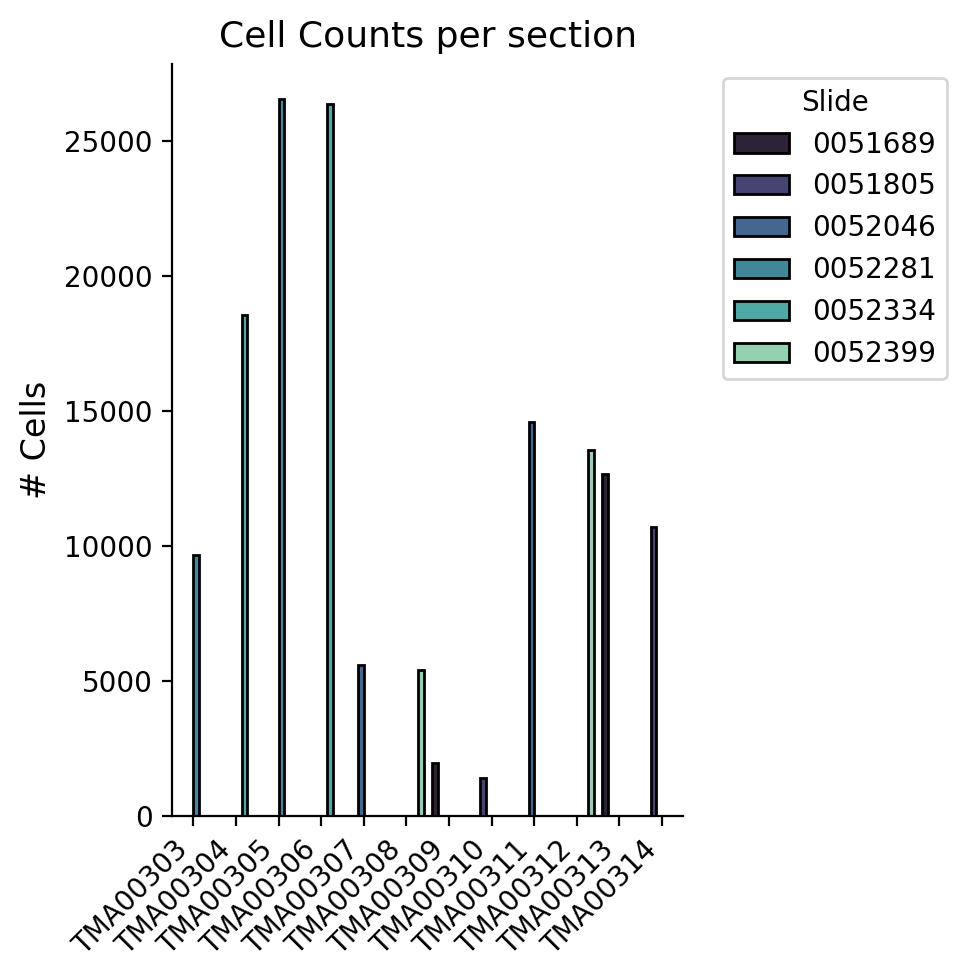

In [11]:
# Count cells per (slide, sample_id)
grouped = (
    adata.obs.groupby(["sample_id", "slide_id"])
    .size()
    .reset_index(name="count")
)

# Order sections consistently
section_order = sorted(adata.obs["sample_id"].unique(), key=str)
grouped["sample_id"] = pd.Categorical(grouped["sample_id"], categories=section_order, ordered=True)

# Plot
plt.figure(figsize=(5,5))
sns.barplot(
    data=grouped,
    x="sample_id",
    y="count",
    hue="slide_id",
    palette="mako",
    edgecolor="black"
)

plt.ylabel("# Cells", fontsize=12)
plt.xlabel("", fontsize=12)
plt.title("Cell Counts per section", fontsize=13)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.legend(title="Slide", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_14359/446737720.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("sample_id")["total_counts"]
/tmp/ipykernel_14359/446737720.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


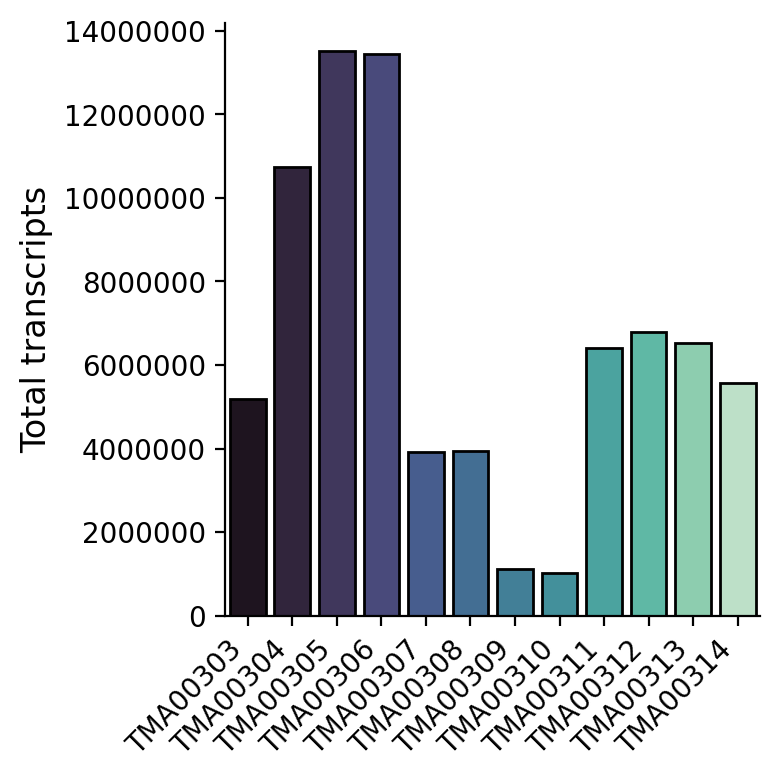

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Summarize total transcripts per sample_id  (FIXED)
grouped_total = (
    adata.obs.groupby("sample_id")["total_counts"]
    .sum()
    .reset_index(name="total_transcripts")
)

# Order sample IDs consistently
section_order = sorted(adata.obs["sample_id"].unique(), key=str)
grouped_total["sample_id"] = pd.Categorical(
    grouped_total["sample_id"], 
    categories=section_order, 
    ordered=True
)

# --- Disable scientific notation ---
plt.figure(figsize=(4, 4))
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y')

# Plot (mako palette)
sns.barplot(
    data=grouped_total,
    x="sample_id",
    y="total_transcripts",
    palette="mako",
    edgecolor="black"
)

plt.ylabel("Total transcripts", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=45, ha="right", fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

In [23]:
adata.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id',
       'output_id', 'region_id', 'slide_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch'],
      dtype='object')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


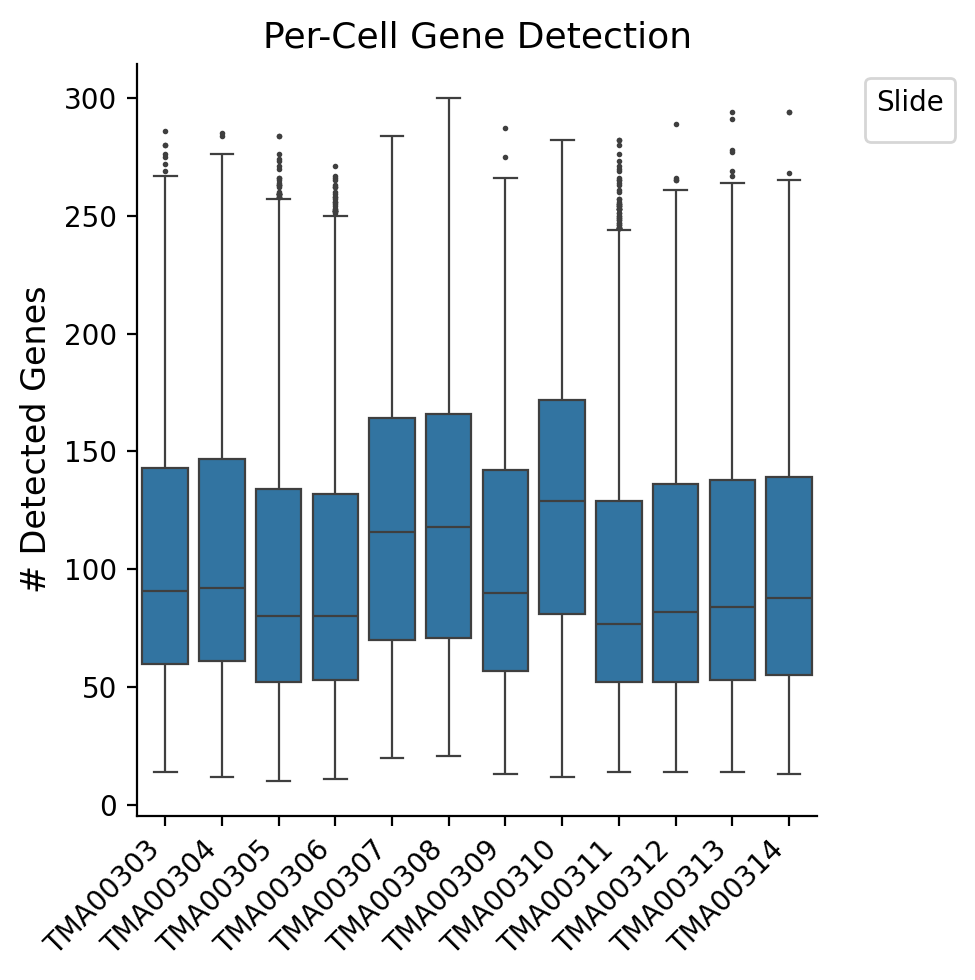

In [14]:
plt.figure(figsize=(5, 5))
sns.boxplot(
    data=adata.obs,
    x="sample_id",
    y="n_genes_by_counts",
    #hue="slide",
    #palette="Paired",
    fliersize=1,
    linewidth=0.8
)

plt.ylabel("# Detected Genes", fontsize=12)
plt.xlabel("", fontsize=12)
plt.title("Per-Cell Gene Detection", fontsize=13)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.legend(title="Slide", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


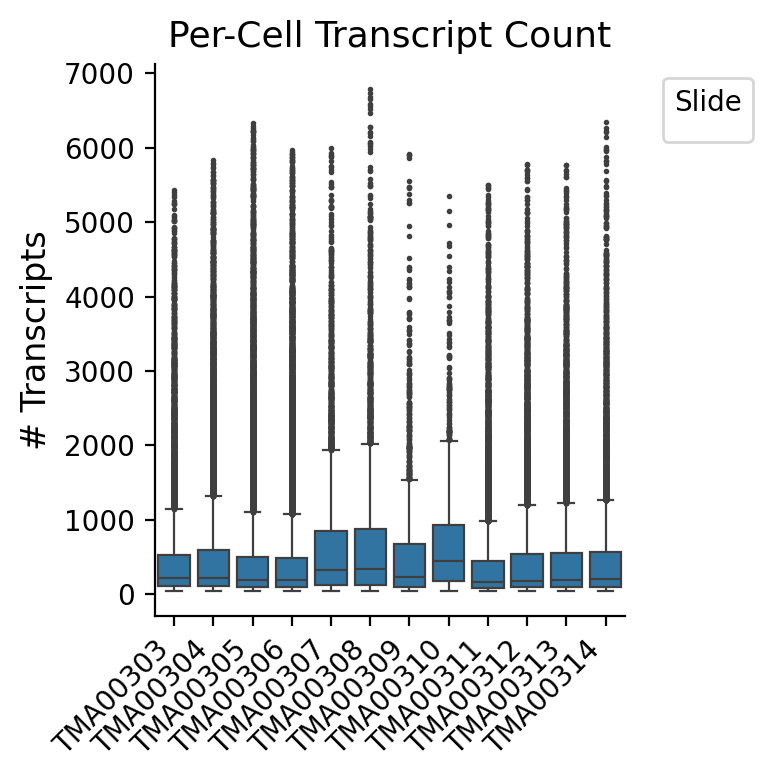

In [29]:
plt.figure(figsize=(4, 4))
sns.boxplot(
    data=adata.obs,
    x="sample_id",
    y="total_counts",
    #hue="slide",
    #palette="Paired",
    fliersize=1,
    linewidth=0.8
)

plt.ylabel("# Transcripts", fontsize=12)
plt.xlabel("", fontsize=12)
plt.title("Per-Cell Transcript Count", fontsize=13)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.legend(title="Slide", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_14359/451372278.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


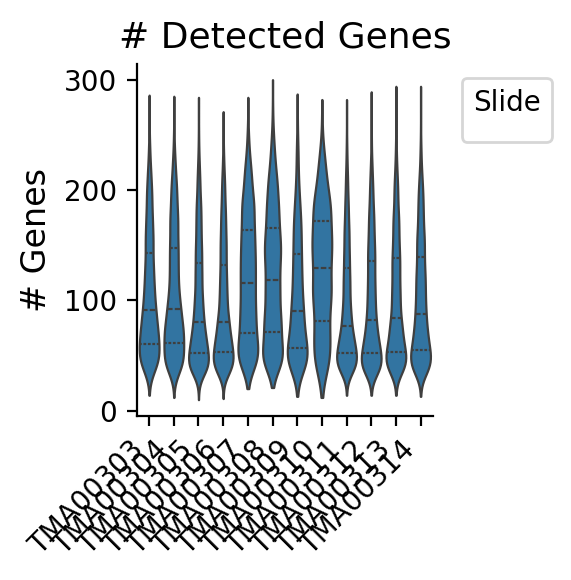

In [16]:
plt.figure(figsize=(3, 3))
sns.violinplot(
    data=adata.obs,
    x="sample_id",
    y="n_genes_by_counts",
    #hue="slide",
    #palette="Paired",
    cut=0,             # don’t extend beyond observed range
    scale="width",     # equalize width across groups
    linewidth=0.8,
    inner="quartile"   # show median & quartiles
)

plt.ylabel("# Genes", fontsize=12)
plt.xlabel("", fontsize=12)
plt.title("# Detected Genes", fontsize=13)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.legend(title="Slide", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_14359/238893763.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


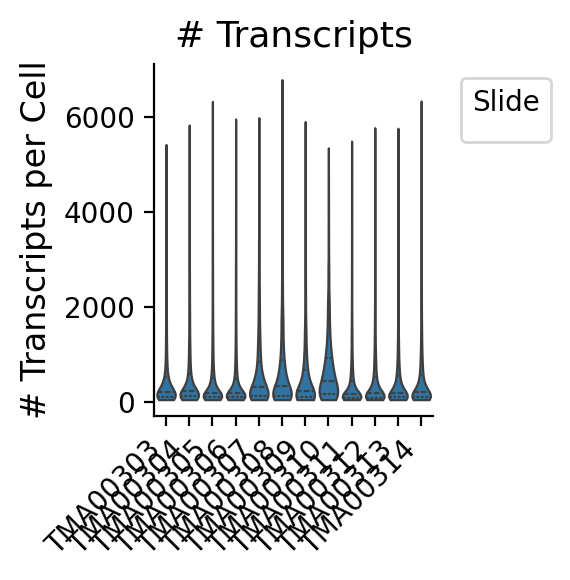

In [17]:
plt.figure(figsize=(3, 3))
sns.violinplot(
    data=adata.obs,
    x="sample_id",
    y="total_counts",
    #hue="slide",
    #palette="Paired",
    cut=0,             # trims violins to the data range
    scale="width",     # keeps widths comparable
    linewidth=0.8,
    inner="quartile"   # show median and quartiles
)

plt.ylabel("# Transcripts per Cell", fontsize=12)
plt.xlabel("", fontsize=12)
plt.title("# Transcripts", fontsize=13)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.legend(title="Slide", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_14359/2006959026.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


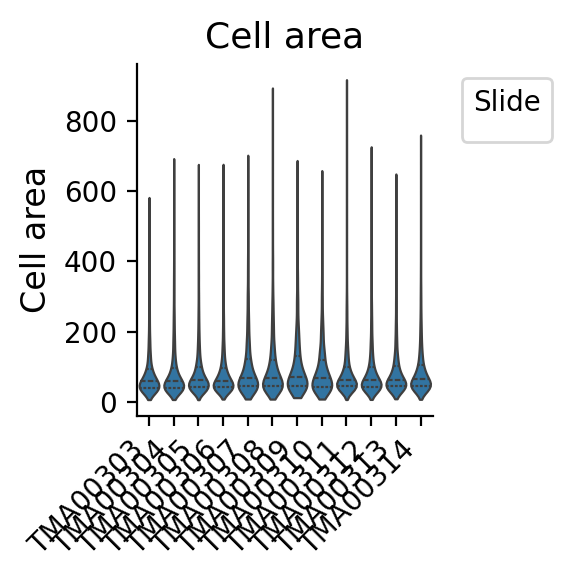

In [18]:
plt.figure(figsize=(3, 3))
sns.violinplot(
    data=adata.obs,
    x="sample_id",
    y="cell_area",
    #hue="slide",
    #palette="Paired",
    cut=0,             # trims violins to the data range
    scale="width",     # keeps widths comparable
    linewidth=0.8,
    inner="quartile"   # show median and quartiles
)

plt.ylabel("Cell area", fontsize=12)
plt.xlabel("", fontsize=12)
plt.title("Cell area", fontsize=13)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.legend(title="Slide", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
print(f"Total cells: {adata.n_obs:,}")
print(f"Median transcripts per cell: {adata.obs['total_counts'].median():,.0f}")
print(f"Median detected genes per cell: {adata.obs['n_genes_by_counts'].median():,.0f}")

Total cells: 147,036
Median transcripts per cell: 202
Median detected genes per cell: 86
